In [ ]:
from algs.pca_fft import PCA_FFT
from tasks.safety_monitor import *
from algs.cd_poly import CDPolynomial

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

In [ ]:
def kld(x, n_components):
    n, N, C = x.shape
    x = x.reshape((n, N*C))
    z = PCA(n_components=n_components).fit_transform(x)
    return z

In [39]:
n = 100  # num signals
N = 100 # num steps
C = 100 # num channels
t = np.linspace(0, 1, num=N)
eps = 0.1 * np.random.rand(n, N, C)

In [53]:
task = SafetyMonitor('humanoid', SafetyMonitorConfig(win=22, hor=30))
x_tr, x = task.get_train_test()
y = task.y_true
x.shape

Sampled windows from 1000 / 1000 trajectories


(1000, 22, 348)

In [ ]:
pca = PCA_FFT(k1=0.9, k2=2).fit(x[~y])
z = pca.transform(x)

Fit PCA-FFT with k1 = 20 and k2 = 2.


In [58]:
window = 22
starts = np.random.randint(low=100, high=x_tr.shape[1] - window + 1, size=len(x_tr))
idx = starts[:, None] + np.arange(window)[None, :]
x_tr = x_tr[np.arange(len(x_tr))[:, None], idx]
z_tr = pca.transform(x_tr)

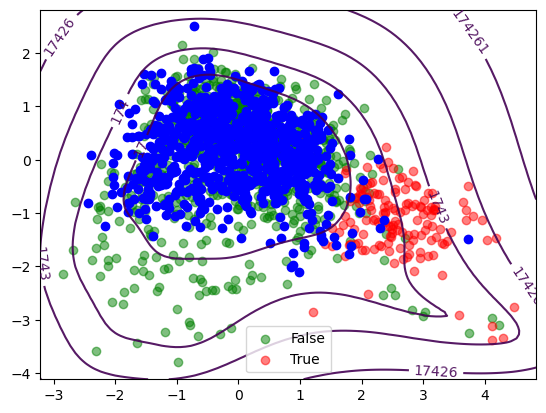

In [60]:
p = CDPolynomial(z[~y], degree=5, eps=1e-1, method='chol')

plt.scatter(z[y==False, 0], z[y==False, 1], c='green',  label='False', alpha=0.5)
plt.scatter(z[y==True,  0], z[y==True,  1], c='red',   label='True', alpha=0.5)
plt.scatter(*z_tr.T, c='blue')

p.plot(plt.gca())
plt.legend()
plt.show()

Fit PCA-FFT with k1 = 31 and k2 = 3.


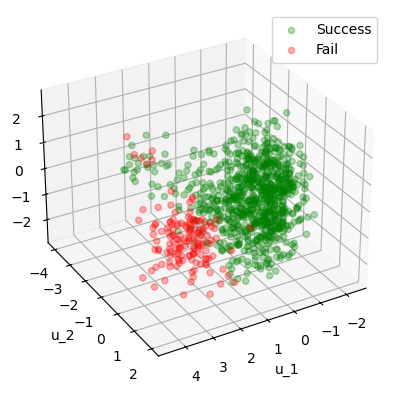

In [51]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

pca = PCA_FFT(k1=0.95, k2=3).fit(x[~y])
z = pca.transform(x)

#z = kld(x, 3)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(z[y==False, 0], z[y==False, 1], z[y==False, 2], c='green', label='Success', alpha=0.3)
ax.scatter(z[y==True, 0], z[y==True, 1], z[y==True, 2], c='red', label='Fail', alpha=0.3)

ax.set_xlabel('u_1')
ax.set_ylabel('u_2')
ax.set_zlabel('u_3')

ax.view_init(elev=30, azim=60)

#plt.title('PCA-FFT applied to Humanoid trajectory windows')

ax.legend()
plt.show()


In [10]:
ood_idx = [2, 33, 77, 90, 91]
ood_chan = np.random.randint(0, C, size=((len(ood_idx), 5)))

x = np.zeros((n, N, C))

x = np.sin(2*np.pi*t)[None, :, None] + eps
#x = np.random.rand(n, N, C)

for idx, i in enumerate(ood_idx):
    for j in ood_chan[idx]:
        #x[i,:,j] = np.sin(2*np.pi*t) + eps[i, :, j]
        x[i,:,j] = np.random.rand(N)

y = np.full((n,), False)
y[ood_idx] = True
x.shape

(100, 100, 100)

Fit PCA-FFT with k1 = 1 and k2 = 2.
Fit PCA-FFT with k1 = 1 and k2 = 2.
Fit PCA-FFT with k1 = 2 and k2 = 2.


Text(0.5, 1.0, 'Fit on failure data')

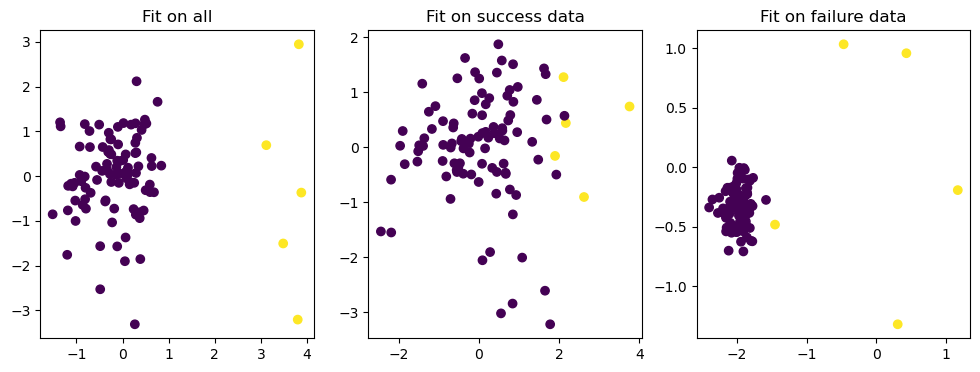

In [142]:
fig, ax = plt.subplots(1, 3, figsize=(12, 4))

pca = PCA_FFT(k1=0.95, k2=2).fit(x)
z = pca.transform(x)
ax[0].scatter(*z.T, c=y)
ax[0].set_title('Fit on all')

pca = PCA_FFT(k1=0.95, k2=2).fit(x[~y])
z = pca.transform(x)
ax[1].scatter(*z.T, c=y)
ax[1].set_title('Fit on success data')

pca = PCA_FFT(k1=0.95, k2=2).fit(x[y])
z = pca.transform(x)
ax[2].scatter(*z.T, c=y)
ax[2].set_title('Fit on failure data')